1. File hasil ekstraksi dikelompokkan **per label** (`Kelas_0.xlsx` s/d `Kelas_3.xlsx`) + `Semua_Label.xlsx`.
2. Scatter plot tampil **langsung di bawah cell**, memakai **2 warna** (Aktual = biru, Prediksi = oranye).
3. Hasil prediksi Random Forest disimpan di file Excel **tersendiri** (`Hasil_Prediksi_RandomForest.xlsx`).
4. Ground truth dari rumus Arnon disimpan di file Excel **tersendiri** juga (`Ground_Truth_Absorbansi_Arnon.xlsx`).


In [ ]:
import os
import glob
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                              r2_score, mean_absolute_percentage_error)

from openpyxl import Workbook
from openpyxl.drawing.image import Image as XLImage
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

FOLDER_DATASET_ASLI = r"c:\Users\Balqoz\skripsiku\Dataset Asli"                 
FILE_ABSORBANSI     = r"C:\Users\Balqoz\skripsiku\Data Absorbansi\Latihan UV Vis 21 Juli 2022.xlsx"
FOLDER_OUTPUT       = r"C:\Users\Balqoz\skripsiku\Hasil_Ekstraksi"    
os.makedirs(FOLDER_OUTPUT, exist_ok=True)

POLA_REGEX = r"R=\s*([\d.]+)\s*G=\s*([\d.]+)\s*B=\s*([\d.]+)\s*(\d+)\s*%"
FITUR = ["R", "G", "B", "IR", "ExG"]
TARGETS = ["Klorofil_A", "Klorofil_B", "Total_Klorofil"]

## `ekstrak_satu_file`
Fungsi bantu ekstraksi 1 file mentah (dipanggil otomatis oleh proses_semua_file).

In [ ]:
def ekstrak_satu_file(file_path: str, label: int, tanaman_ke: int) -> pd.DataFrame:
    df_raw = pd.read_excel(file_path, header=None)
    hasil = df_raw[0].astype(str).str.extract(POLA_REGEX)
    hasil.columns = ["R", "G", "B", "IR"]
    hasil = hasil.apply(pd.to_numeric, errors="coerce")
    hasil.dropna(inplace=True)
    hasil["ExG"] = (2 * hasil["G"]) - hasil["R"] - hasil["B"]
    hasil["Perlakuan"] = label
    hasil["Tanaman_Ke"] = tanaman_ke
    return hasil

## `proses_semua_file`
Ekstraksi seluruh file, dikelompokkan per label (Kelas_0..3.xlsx + Semua_Label.xlsx)

In [ ]:
def proses_semua_file():
    print("=" * 70)
    print("Ekstraksi RGB+IR+ExG, dikelompokkan PER LABEL")
    print("=" * 70)

    files = sorted(glob.glob(os.path.join(FOLDER_DATASET_ASLI, "HH*.xlsx")))
    print(f"Ditemukan {len(files)} file: {[os.path.basename(f) for f in files]}\n")

    per_label = {0: [], 1: [], 2: [], 3: []}
    daftar_ringkasan = []

    for file_path in files:
        nama = os.path.splitext(os.path.basename(file_path))[0]
        label = int(nama[2])
        ulangan = int(nama[3])

        detail = ekstrak_satu_file(file_path, label, ulangan)
        per_label[label].append(detail)

        ringkasan = detail[["R", "G", "B", "IR", "ExG"]].mean(numeric_only=True).to_dict()
        ringkasan["Perlakuan"] = label
        ringkasan["Tanaman_Ke"] = ulangan
        ringkasan["Nama_File"] = nama
        daftar_ringkasan.append(ringkasan)

        print(f"  [{nama}] label={label}, tanaman ke-{ulangan}, "
              f"{len(detail)} baris valid -> rata-rata ExG={ringkasan['ExG']:.2f}")

    # --- Simpan 1 file per label (gabungan semua baris tanaman dalam label itu) ---
    semua_label_list = []
    for label, daftar_df in per_label.items():
        df_kelas = pd.concat(daftar_df, ignore_index=True)
        df_kelas = df_kelas[["R", "G", "B", "IR", "ExG", "Perlakuan", "Tanaman_Ke"]]
        path_kelas = os.path.join(FOLDER_OUTPUT, f"Kelas_{label}.xlsx")
        df_kelas.to_excel(path_kelas, index=False)
        semua_label_list.append(df_kelas)
        print(f"\n  >> Kelas_{label}.xlsx tersimpan ({len(df_kelas)} baris, "
              f"gabungan {len(daftar_df)} tanaman)")

    # --- Simpan 1 file gabungan semua label ---
    df_semua_label = pd.concat(semua_label_list, ignore_index=True)
    path_semua = os.path.join(FOLDER_OUTPUT, "Semua_Label.xlsx")
    df_semua_label.to_excel(path_semua, index=False)
    print(f"\n  >> Semua_Label.xlsx tersimpan ({len(df_semua_label)} baris total)\n")

    # --- Ringkasan rata-rata per tanaman (16 baris) untuk training ---
    df_fitur = pd.DataFrame(daftar_ringkasan)
    df_fitur = df_fitur[["Nama_File", "Perlakuan", "Tanaman_Ke", "R", "G", "B", "IR", "ExG"]]
    path_fitur = os.path.join(FOLDER_OUTPUT, "Dataset_Fitur_16_Tanaman.xlsx")
    df_fitur.to_excel(path_fitur, index=False)
    print(f">> Ringkasan fitur 16 tanaman tersimpan di: {path_fitur}\n")

    return df_fitur

In [ ]:
# Menampilkan hasil ekstraksi semua file
df_fitur = proses_semua_file()

Ekstraksi RGB+IR+ExG, dikelompokkan PER LABEL
Ditemukan 16 file: ['HH01.xlsx', 'HH02.xlsx', 'HH03.xlsx', 'HH04.xlsx', 'HH11.xlsx', 'HH12.xlsx', 'HH13.xlsx', 'HH14.xlsx', 'HH21.xlsx', 'HH22.xlsx', 'HH23.xlsx', 'HH24.xlsx', 'HH31.xlsx', 'HH32.xlsx', 'HH33.xlsx', 'HH34.xlsx']

  [HH01] label=0, tanaman ke-1, 75 baris valid -> rata-rata ExG=35.54
  [HH02] label=0, tanaman ke-2, 101 baris valid -> rata-rata ExG=40.06
  [HH03] label=0, tanaman ke-3, 78 baris valid -> rata-rata ExG=40.05
  [HH04] label=0, tanaman ke-4, 72 baris valid -> rata-rata ExG=49.73
  [HH11] label=1, tanaman ke-1, 82 baris valid -> rata-rata ExG=38.29
  [HH12] label=1, tanaman ke-2, 75 baris valid -> rata-rata ExG=37.77
  [HH13] label=1, tanaman ke-3, 89 baris valid -> rata-rata ExG=36.23
  [HH14] label=1, tanaman ke-4, 122 baris valid -> rata-rata ExG=33.73
  [HH21] label=2, tanaman ke-1, 102 baris valid -> rata-rata ExG=33.21
  [HH22] label=2, tanaman ke-2, 88 baris valid -> rata-rata ExG=32.54
  [HH23] label=2, tana

## `hitung_ground_truth_klorofil`
Hitung ground truth klorofil dari absorbansi asli (rumus Arnon) -> file Excel tersendiri.

In [ ]:
def hitung_ground_truth_klorofil():
    print("=" * 70)
    print("Ground truth klorofil dari absorbansi ASLI (rumus Arnon)")
    print("=" * 70)

    df_abs = pd.read_excel(FILE_ABSORBANSI)
    A645 = df_abs[645].iloc[0:4].values
    A663_proxy = df_abs[665].iloc[0:4].values     # proksi 663nm (alat scan tiap 5nm)
    A665 = df_abs[665].iloc[0:4].values
    A669_proxy = df_abs[670].iloc[0:4].values     # proksi 669nm

    df_gt = pd.DataFrame({
        "Perlakuan": [0, 1, 2, 3],
        "A645": A645,
        "A663_proxy(665nm)": A663_proxy,
        "A665": A665,
        "A669_proxy(670nm)": A669_proxy,
    })
    df_gt["Klorofil_A"] = 12.7 * df_gt["A663_proxy(665nm)"] - 2.69 * df_gt["A645"]
    df_gt["Klorofil_B"] = 22.9 * df_gt["A645"] - 4.68 * df_gt["A669_proxy(670nm)"]
    df_gt["Total_Klorofil"] = 20.2 * df_gt["A645"] + 8.02 * df_gt["A665"]

    # --- FILE EXCEL KHUSUS: absorbansi + target klorofil (rumus Arnon) ---
    path_gt = os.path.join(FOLDER_OUTPUT, "Ground_Truth_Absorbansi_Arnon.xlsx")
    df_gt.to_excel(path_gt, index=False)
    print(df_gt.to_string(index=False))
    print(f"\n>> File KHUSUS ground truth Arnon tersimpan di: {path_gt}\n")
    return df_gt

In [ ]:
# Menghitung hasil ground truth klorofil dari absorbansi
df_gt = hitung_ground_truth_klorofil()

Ground truth klorofil dari absorbansi ASLI (rumus Arnon)
 Perlakuan   A645  A663_proxy(665nm)   A665  A669_proxy(670nm)  Klorofil_A  Klorofil_B  Total_Klorofil
         0 0.6494             0.6247 0.6247             0.6179    6.186804   11.979488       18.127974
         1 0.6959             0.6780 0.6780             0.6719    6.738629   12.791618       19.494740
         2 0.6960             0.6781 0.6781             0.6720    6.739630   12.793440       19.497562
         3 0.7056             0.6888 0.6888             0.6822    6.849696   12.965544       19.777296

>> File KHUSUS ground truth Arnon tersimpan di: C:\Users\Balqoz\skripsiku\Hasil_Ekstraksi\Ground_Truth_Absorbansi_Arnon.xlsx



## `gabungkan_dataset_final`
Gabungkan fitur (16 tanaman) dengan ground truth (broadcast per label)

In [ ]:
def gabungkan_dataset_final(df_fitur, df_gt):
    print("=" * 70)
    print("Gabungkan fitur (16 tanaman) + ground truth (per label)")
    print("=" * 70)

    df_final = df_fitur.merge(df_gt[["Perlakuan"] + TARGETS], on="Perlakuan", how="left")
    kolom_akhir = ["Nama_File", "Perlakuan", "Tanaman_Ke"] + FITUR + TARGETS
    df_final = df_final[kolom_akhir]

    path_final = os.path.join(FOLDER_OUTPUT, "Dataset_Final_Siap_Training.xlsx")
    df_final.to_excel(path_final, index=False)
    print(df_final.to_string(index=False))
    print(f"\n>> Dataset final (fitur+target, untuk training) tersimpan di: {path_final}\n")
    return df_final

In [ ]:
# Menampilkan hasil gabungan dataset final (fitur + ground truth)
df_final = gabungkan_dataset_final(df_fitur, df_gt)

Gabungkan fitur (16 tanaman) + ground truth (per label)
Nama_File  Perlakuan  Tanaman_Ke          R          G          B        IR       ExG  Klorofil_A  Klorofil_B  Total_Klorofil
     HH01          0           1 148.693333 150.792000 117.351200 71.880000 35.539467    6.186804   11.979488       18.127974
     HH02          0           2 143.643564 147.645545 111.587129 89.643564 40.060396    6.186804   11.979488       18.127974
     HH03          0           3 143.641026 146.476923 109.260000 69.858974 40.052821    6.186804   11.979488       18.127974
     HH04          0           4 130.722222 136.500000  92.551389 68.111111 49.726389    6.186804   11.979488       18.127974
     HH11          1           1 151.890244 152.248780 114.314146 75.865854 38.293171    6.738629   12.791618       19.494740
     HH12          1           2 146.933333 150.376000 116.044267 74.973333 37.774400    6.738629   12.791618       19.494740
     HH13          1           3 145.550562 148.325843 114.868

## `training_dan_evaluasi_loocv`
Training Random Forest dengan LOOCV, hitung metrik evaluasi (MAE, MSE, R2, MAPE).

In [ ]:
def training_dan_evaluasi_loocv(df_final):
    print("=" * 70)
    print("Training Random Forest dengan LOOCV (per target klorofil)")
    print("=" * 70)

    X = df_final[FITUR].values
    loo = LeaveOneOut()

    hasil_prediksi = {}
    tabel_metrik = []

    for target in TARGETS:
        y = df_final[target].values
        preds = np.zeros(len(y))

        for train_idx, test_idx in loo.split(X):
            model = RandomForestRegressor(n_estimators=100, max_depth=None, random_state=42)
            model.fit(X[train_idx], y[train_idx])
            preds[test_idx] = model.predict(X[test_idx])

        hasil_prediksi[target] = preds

        mae = mean_absolute_error(y, preds)
        mse = mean_squared_error(y, preds)
        r2 = r2_score(y, preds)
        mape = mean_absolute_percentage_error(y, preds) * 100
        tabel_metrik.append({"Target": target, "MAE": mae, "MSE": mse, "R2": r2, "MAPE (%)": mape})

        print(f"\n-------- {target.upper()} --------")
        print(f"R2 Score : {r2:.4f}")
        print(f"MAE      : {mae:.4f}")
        print(f"MSE      : {mse:.4f}")
        print(f"MAPE     : {mape:.2f}%")

    df_metrik = pd.DataFrame(tabel_metrik)
    print("\n" + "=" * 70)
    print("RINGKASAN METRIK EVALUASI (LOOCV)")
    print("=" * 70)
    print(df_metrik.to_string(index=False))
    return hasil_prediksi, df_metrik

In [ ]:
# Menampilkan hasil training dan evaluasi LOOCV
hasil_prediksi, df_metrik = training_dan_evaluasi_loocv(df_final)

Training Random Forest dengan LOOCV (per target klorofil)

-------- KLOROFIL_A --------
R2 Score : -0.5065
MAE      : 0.2586
MSE      : 0.1011
MAPE     : 3.97%

-------- KLOROFIL_B --------
R2 Score : -0.5062
MAE      : 0.3824
MSE      : 0.2216
MAPE     : 3.06%

-------- TOTAL_KLOROFIL --------
R2 Score : -0.4799
MAE      : 0.6303
MSE      : 0.6125
MAPE     : 3.33%

RINGKASAN METRIK EVALUASI (LOOCV)
        Target      MAE      MSE        R2  MAPE (%)
    Klorofil_A 0.258636 0.101122 -0.506461  3.966669
    Klorofil_B 0.382429 0.221626 -0.506220  3.064760
Total_Klorofil 0.630252 0.612511 -0.479900  3.325553


## `buat_scatter_plot`
Scatter plot Aktual (biru) vs Prediksi (oranye)

In [ ]:
def buat_scatter_plot(df_final, hasil_prediksi):
    print("=" * 70)
    print("Scatter plot Aktual (biru) vs Prediksi (oranye) per sampel")
    print("=" * 70)

    label_judul = {"Klorofil_A": "Chlorophyll a", "Klorofil_B": "Chlorophyll b",
                   "Total_Klorofil": "Total Chlorophyll"}
    path_gambar = {}

    x_idx = np.arange(len(df_final))
    x_ticklabel = df_final["Nama_File"].tolist()

    for target in TARGETS:
        y_actual = df_final[target].values
        y_pred = hasil_prediksi[target]

        plt.figure(figsize=(9, 4.5))
        plt.scatter(x_idx, y_actual, color="#2E86C1", s=80, marker="o",
                    label="Aktual (Arnon)", zorder=3)
        plt.scatter(x_idx, y_pred, color="#F39C12", s=80, marker="^",
                    label="Prediksi (Random Forest, LOOCV)", zorder=3)

        # garis penghubung tipis supaya pola per sampel kelihatan
        plt.plot(x_idx, y_actual, color="#2E86C1", alpha=0.3, linewidth=1, zorder=2)
        plt.plot(x_idx, y_pred, color="#F39C12", alpha=0.3, linewidth=1, zorder=2)

        plt.xticks(x_idx, x_ticklabel, rotation=45, ha="right", fontsize=8)
        plt.title(f"Aktual vs Prediksi - {label_judul[target]} (Random Forest, LOOCV)",
                  fontsize=11, fontweight="bold")
        plt.xlabel("Sampel Tanaman")
        plt.ylabel("Nilai Klorofil")
        plt.grid(True, linestyle=":", alpha=0.5)
        plt.legend(loc="best", fontsize=9)
        plt.tight_layout()

        path_png = os.path.join(FOLDER_OUTPUT, f"Scatter_{target}.png")
        plt.savefig(path_png, dpi=150)
        plt.show()          # <-- supaya tampil langsung di bawah cell notebook
        plt.close()

        path_gambar[target] = path_png
        print(f"  Scatter plot {target} juga tersimpan di: {path_png}\n")

    return path_gambar

Scatter plot Aktual (biru) vs Prediksi (oranye) per sampel


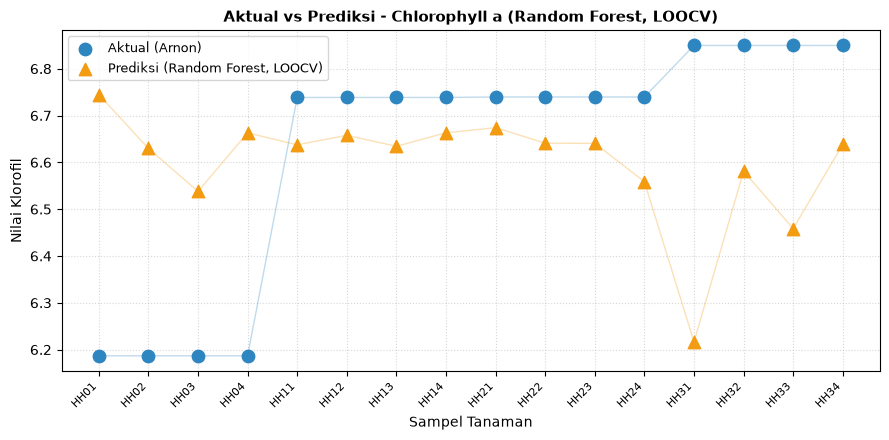

  Scatter plot Klorofil_A juga tersimpan di: C:\Users\Balqoz\skripsiku\Hasil_Ekstraksi\Scatter_Klorofil_A.png



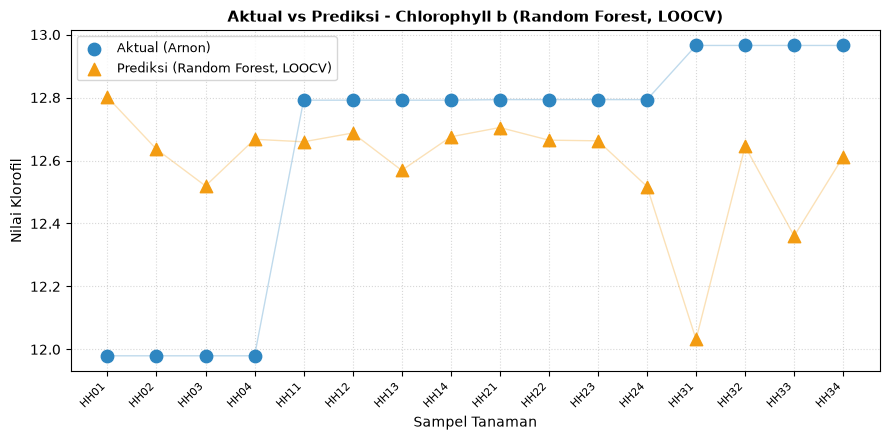

  Scatter plot Klorofil_B juga tersimpan di: C:\Users\Balqoz\skripsiku\Hasil_Ekstraksi\Scatter_Klorofil_B.png



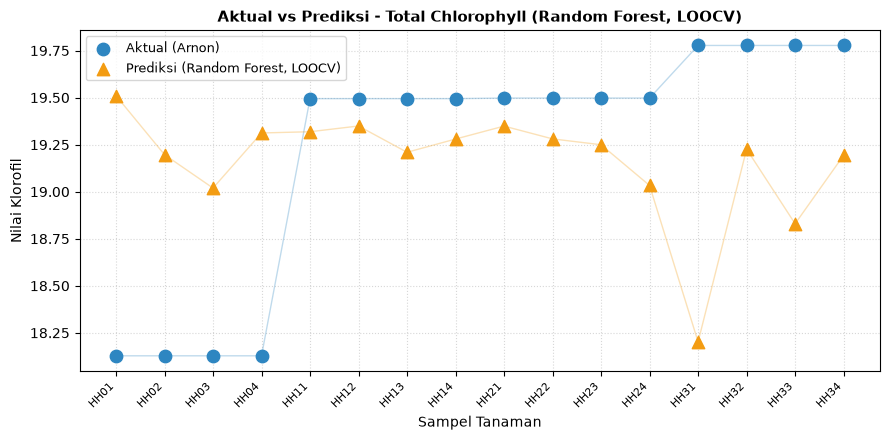

  Scatter plot Total_Klorofil juga tersimpan di: C:\Users\Balqoz\skripsiku\Hasil_Ekstraksi\Scatter_Total_Klorofil.png



In [ ]:
# Menampilkan hasil scatter plot Aktual vs Prediksi per target klorofil
path_gambar = buat_scatter_plot(df_final, hasil_prediksi)

## `simpan_model_final`
Training model final (seluruh 16 data) dan simpan sebagai .pkl.

In [ ]:
def simpan_model_final(df_final):
    print("=" * 70)
    print("Training model final (seluruh 16 data) & simpan .pkl")
    print("=" * 70)

    X = df_final[FITUR].values
    nama_file_model = {"Klorofil_A": "model_rf_a.pkl",
                        "Klorofil_B": "model_rf_b.pkl",
                        "Total_Klorofil": "model_rf_total.pkl"}

    for target in TARGETS:
        y = df_final[target].values
        model = RandomForestRegressor(n_estimators=100, max_depth=None, random_state=42)
        model.fit(X, y)
        joblib.dump(model, nama_file_model[target])
        print(f"  Model untuk {target} disimpan di: {nama_file_model[target]}")

    print(f"\n>> Fitur yang dipakai model (URUTAN INI HARUS SAMA saat prediksi di app.py):")
    print(f"   {FITUR}\n")

In [ ]:
# Menyimpan model final (seluruh 16 data) ke file .pkl
simpan_model_final(df_final)

Training model final (seluruh 16 data) & simpan .pkl
  Model untuk Klorofil_A disimpan di: model_rf_a.pkl
  Model untuk Klorofil_B disimpan di: model_rf_b.pkl
  Model untuk Total_Klorofil disimpan di: model_rf_total.pkl

>> Fitur yang dipakai model (URUTAN INI HARUS SAMA saat prediksi di app.py):
   ['R', 'G', 'B', 'IR', 'ExG']



## `export_excel_hasil_rf`
Export hasil Random Forest (fitur+prediksi+metrik+scatter) ke file Excel

In [ ]:
def export_excel_hasil_rf(df_final, hasil_prediksi, df_metrik, path_gambar):
    print("=" * 70)
    print("Export hasil Random Forest ke file Excel TERSENDIRI")
    print("=" * 70)

    FONT = "Arial"
    HEADER_FILL = PatternFill("solid", start_color="1F4E78", end_color="1F4E78")
    HEADER_FONT = Font(name=FONT, bold=True, color="FFFFFF")
    TITLE_FONT = Font(name=FONT, bold=True, size=13)
    NOTE_FONT = Font(name=FONT, italic=True, size=9, color="808080")
    thin = Side(style="thin", color="BFBFBF")
    BORDER = Border(left=thin, right=thin, top=thin, bottom=thin)

    wb = Workbook()

    # ---- Sheet 1: Fitur (RGB+IR+ExG) + Prediksi Klorofil A/B/Total ----
    ws1 = wb.active
    ws1.title = "1_Prediksi_RandomForest"
    ws1["A1"] = "HASIL PREDIKSI RANDOM FOREST DARI FITUR RGB + IR + ExG"
    ws1["A1"].font = TITLE_FONT
    ws1["A2"] = "Prediksi memakai skema LOOCV (setiap sampel diprediksi oleh model yang TIDAK dilatih dengan sampel itu sendiri)"
    ws1["A2"].font = NOTE_FONT
    ws1.merge_cells("A2:L2")

    headers = ["Nama_File", "Perlakuan"] + FITUR + \
              [f"Prediksi_{t}" for t in TARGETS]
    for j, h in enumerate(headers, start=1):
        c = ws1.cell(row=4, column=j, value=h)
        c.fill = HEADER_FILL; c.font = HEADER_FONT; c.border = BORDER
        c.alignment = Alignment(horizontal="center", wrap_text=True)

    for i in range(len(df_final)):
        r = 5 + i
        row = df_final.iloc[i]
        ws1.cell(row=r, column=1, value=row["Nama_File"])
        ws1.cell(row=r, column=2, value=int(row["Perlakuan"]))
        col = 3
        for f in FITUR:
            ws1.cell(row=r, column=col, value=round(float(row[f]), 4)); col += 1
        for t in TARGETS:
            ws1.cell(row=r, column=col, value=round(float(hasil_prediksi[t][i]), 4)); col += 1
        for c in range(1, len(headers) + 1):
            ws1.cell(row=r, column=c).border = BORDER
            ws1.cell(row=r, column=c).alignment = Alignment(horizontal="center")

    for i, w in enumerate([12, 10] + [10] * len(FITUR) + [16] * len(TARGETS), start=1):
        ws1.column_dimensions[get_column_letter(i)].width = w

    # ---- Sheet 2: Tabel Metrik Evaluasi (LOOCV) ----
    ws2 = wb.create_sheet("2_Tabel_Metrik_Evaluasi")
    ws2["A1"] = "TABEL METRIK EVALUASI MODEL RANDOM FOREST (LOOCV)"
    ws2["A1"].font = TITLE_FONT
    headers2 = ["Target", "R2", "MAE", "MSE", "MAPE (%)"]
    for j, h in enumerate(headers2, start=1):
        c = ws2.cell(row=3, column=j, value=h)
        c.fill = HEADER_FILL; c.font = HEADER_FONT; c.border = BORDER
        c.alignment = Alignment(horizontal="center")
    for i in range(len(df_metrik)):
        r = 4 + i
        row = df_metrik.iloc[i]
        ws2.cell(row=r, column=1, value=row["Target"])
        ws2.cell(row=r, column=2, value=round(float(row["R2"]), 4))
        ws2.cell(row=r, column=3, value=round(float(row["MAE"]), 4))
        ws2.cell(row=r, column=4, value=round(float(row["MSE"]), 4))
        ws2.cell(row=r, column=5, value=round(float(row["MAPE (%)"]), 2))
        for c in range(1, 6):
            ws2.cell(row=r, column=c).border = BORDER
            ws2.cell(row=r, column=c).alignment = Alignment(horizontal="center")
    for i, w in enumerate([18, 10, 10, 10, 12], start=1):
        ws2.column_dimensions[get_column_letter(i)].width = w

    # ---- Sheet 3: Scatter Plot (Aktual vs Prediksi, 2 warna) ----
    ws3 = wb.create_sheet("3_Scatter_Plot")
    ws3["A1"] = "VISUALISASI AKTUAL (ARNON) VS PREDIKSI (RANDOM FOREST, LOOCV)"
    ws3["A1"].font = TITLE_FONT

    row_cursor = 3
    for target in TARGETS:
        ws3.cell(row=row_cursor, column=1, value=target).font = Font(name=FONT, bold=True)
        img = XLImage(path_gambar[target])
        img.width, img.height = 650, 320
        ws3.add_image(img, f"A{row_cursor + 1}")
        row_cursor += 18

    path_xlsx = os.path.join(FOLDER_OUTPUT, "Hasil_Prediksi_RandomForest.xlsx")
    wb.save(path_xlsx)
    print(f">> File KHUSUS hasil Random Forest tersimpan di:\n   {path_xlsx}")
    print(f"   (terpisah dari file ground truth 'Ground_Truth_Absorbansi_Arnon.xlsx')\n")
    return path_xlsx

In [ ]:
# Mengkspor hasil prediksi Random Forest ke file Excel 
export_excel_hasil_rf(df_final, hasil_prediksi, df_metrik, path_gambar)

Export hasil Random Forest ke file Excel TERSENDIRI
>> File KHUSUS hasil Random Forest tersimpan di:
   C:\Users\Balqoz\skripsiku\Hasil_Ekstraksi\Hasil_Prediksi_RandomForest.xlsx
   (terpisah dari file ground truth 'Ground_Truth_Absorbansi_Arnon.xlsx')



'C:\\Users\\Balqoz\\skripsiku\\Hasil_Ekstraksi\\Hasil_Prediksi_RandomForest.xlsx'